# Expedia Hotel Recommendations — EDA
Following `docs/eda_checklist.md`.

`train.csv` is 4.07GB / 37.7M rows — the biggest dataset pulled, machine has only ~3GB free RAM, so it is analyzed via a single chunked streaming pass, same approach as Trivago. `destinations.csv` (62,106 rows, 138MB, 149 latent dims) is loaded fully only where needed (shape check), not into every cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

DATA_DIR = "../../data/raw/hospitality/expedia"
TRAIN_PATH = f"{DATA_DIR}/train.csv"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
preview = pd.read_csv(TRAIN_PATH, nrows=100_000)
print("preview shape:", preview.shape)
preview.head()

preview shape: (100000, 24)


,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-08-11 07:46:59,2,3,66,348,48862,2234.2641,12,0,1,...,0,1,8250,1,0,3,2,50,628,1
1,2014-08-11 08:22:12,2,3,66,348,48862,2234.2641,12,0,1,...,0,1,8250,1,1,1,2,50,628,1
2,2014-08-11 08:24:33,2,3,66,348,48862,2234.2641,12,0,0,...,0,1,8250,1,0,1,2,50,628,1
3,2014-08-09 18:05:16,2,3,66,442,35390,913.1932,93,0,0,...,0,1,14984,1,0,1,2,50,1457,80
4,2014-08-09 18:08:18,2,3,66,442,35390,913.6259,93,0,0,...,0,1,14984,1,0,1,2,50,1457,21


In [3]:
preview.dtypes

date_time                        str
site_name                      int64
posa_continent                 int64
user_location_country          int64
user_location_region           int64
user_location_city             int64
orig_destination_distance    float64
user_id                        int64
is_mobile                      int64
is_package                     int64
channel                        int64
srch_ci                          str
srch_co                          str
srch_adults_cnt                int64
srch_children_cnt              int64
srch_rm_cnt                    int64
srch_destination_id            int64
srch_destination_type_id       int64
is_booking                     int64
cnt                            int64
hotel_continent                int64
hotel_country                  int64
hotel_market                   int64
hotel_cluster                  int64
dtype: object

In [4]:
dest_shape = pd.read_csv(f"{DATA_DIR}/destinations.csv", nrows=5)
print("destinations.csv preview shape (5 rows):", dest_shape.shape)
dest_shape.iloc[:, :4]

destinations.csv preview shape (5 rows): (5, 150)


,srch_destination_id,d1,d2,d3
0,0,-2.198657,-2.198657,-2.198657
1,1,-2.181690,-2.181690,-2.181690
2,2,-2.183490,-2.224164,-2.224164
3,3,-2.177409,-2.177409,-2.177409
4,4,-2.189562,-2.187783,-2.194008


## Single chunked pass over train.csv

In [5]:
CHUNK = 2_000_000
dtypes = {
    "site_name": "int16", "posa_continent": "int8", "user_location_country": "int16",
    "user_location_region": "int16", "user_location_city": "int32", "user_id": "int32",
    "is_mobile": "int8", "is_package": "int8", "channel": "int8",
    "srch_adults_cnt": "int8", "srch_children_cnt": "int8", "srch_rm_cnt": "int8",
    "srch_destination_id": "int32", "srch_destination_type_id": "int8",
    "is_booking": "int8", "cnt": "int32", "hotel_continent": "int8",
    "hotel_country": "int16", "hotel_market": "int16", "hotel_cluster": "int8",
}

n_rows = 0
na_counts = None
hotel_cluster_counts = Counter()
is_booking_counts = Counter()
site_name_counts = Counter()
user_set = set()
odd_min, odd_max, odd_sum, odd_n = None, None, 0.0, 0
dt_min, dt_max = None, None
invalid_dates = 0
adults0_count = 0
hash_set = set()
hash_dupes = 0
booking_user_cluster_pairs = set()
booking_cluster_counts = Counter()
booking_user_counts = Counter()

for chunk in pd.read_csv(TRAIN_PATH, dtype=dtypes, parse_dates=["date_time"], chunksize=CHUNK):
    n_rows += len(chunk)
    na = chunk.isna().sum()
    na_counts = na if na_counts is None else na_counts.add(na, fill_value=0)

    hotel_cluster_counts.update(chunk["hotel_cluster"].value_counts().to_dict())
    is_booking_counts.update(chunk["is_booking"].value_counts().to_dict())
    site_name_counts.update(chunk["site_name"].value_counts().to_dict())
    user_set.update(chunk["user_id"].unique())
    adults0_count += (chunk["srch_adults_cnt"] == 0).sum()

    odd = chunk["orig_destination_distance"].dropna()
    if len(odd):
        cmin, cmax = odd.min(), odd.max()
        odd_min = cmin if odd_min is None else min(odd_min, cmin)
        odd_max = cmax if odd_max is None else max(odd_max, cmax)
        odd_sum += odd.sum(); odd_n += len(odd)

    cmin, cmax = chunk["date_time"].min(), chunk["date_time"].max()
    dt_min = cmin if dt_min is None else min(dt_min, cmin)
    dt_max = cmax if dt_max is None else max(dt_max, cmax)

    ci = pd.to_datetime(chunk["srch_ci"], errors="coerce")
    co = pd.to_datetime(chunk["srch_co"], errors="coerce")
    invalid_dates += (co < ci).sum()

    key_hashes = pd.util.hash_pandas_object(
        chunk["user_id"].astype(str) + "|" + chunk["date_time"].astype(str) + "|" + chunk["srch_destination_id"].astype(str) + "|" + chunk["hotel_cluster"].astype(str),
        index=False,
    )
    for h in key_hashes:
        if h in hash_set:
            hash_dupes += 1
        else:
            hash_set.add(h)

    bookings = chunk[chunk["is_booking"] == 1]
    booking_cluster_counts.update(bookings["hotel_cluster"].value_counts().to_dict())
    booking_user_counts.update(bookings["user_id"].value_counts().to_dict())
    booking_user_cluster_pairs.update(zip(bookings["user_id"], bookings["hotel_cluster"]))

print("rows processed:", n_rows)

rows processed: 37670293


## 2. Missing Values

In [6]:
(na_counts / n_rows * 100).round(2).sort_values(ascending=False)

orig_destination_distance    35.90
srch_ci                       0.12
srch_co                       0.12
date_time                     0.00
user_location_country         0.00
user_location_region          0.00
posa_continent                0.00
site_name                     0.00
user_id                       0.00
user_location_city            0.00
is_package                    0.00
is_mobile                     0.00
channel                       0.00
srch_adults_cnt               0.00
srch_children_cnt             0.00
srch_rm_cnt                   0.00
srch_destination_id           0.00
srch_destination_type_id      0.00
is_booking                    0.00
cnt                           0.00
hotel_continent               0.00
hotel_country                 0.00
hotel_market                  0.00
hotel_cluster                 0.00
dtype: float64

## 3. Duplicates

In [7]:
print(f"approx duplicate (user_id, date_time, srch_destination_id, hotel_cluster) keys (hash-based): {hash_dupes} ({hash_dupes/n_rows:.4%})")

approx duplicate (user_id, date_time, srch_destination_id, hotel_cluster) keys (hash-based): 3165 (0.0084%)


## 4. Univariate Analysis

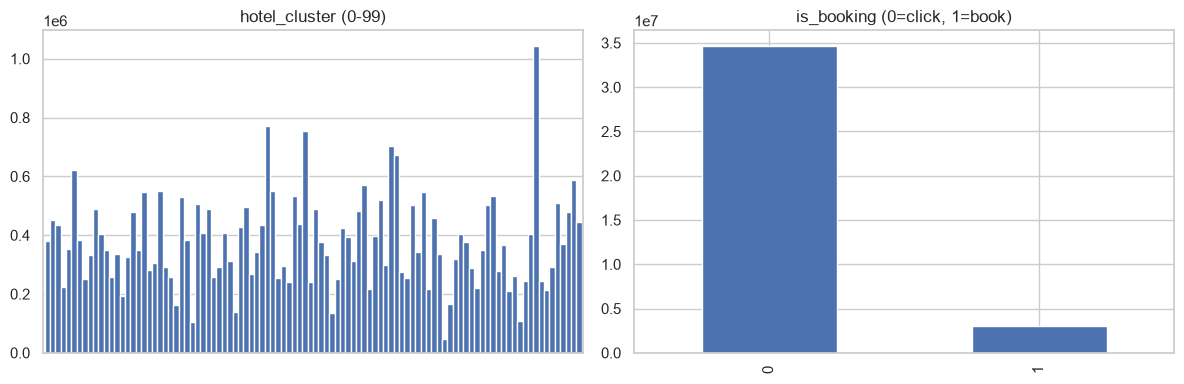

n unique users: 1198786
n unique site_name: 45
orig_destination_distance: min=0.0 max=12407.9 mean=1970.1 (n=24145292)


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(hotel_cluster_counts).sort_index().plot(kind="bar", ax=ax[0], width=1.0); ax[0].set_title("hotel_cluster (0-99)"); ax[0].set_xticks([])
pd.Series(is_booking_counts).plot(kind="bar", ax=ax[1]); ax[1].set_title("is_booking (0=click, 1=book)")
plt.tight_layout(); plt.show()

print("n unique users:", len(user_set))
print("n unique site_name:", len(site_name_counts))
print(f"orig_destination_distance: min={odd_min:.1f} max={odd_max:.1f} mean={odd_sum/odd_n:.1f} (n={odd_n})")

## 5. Outliers

In [9]:
print("srch_adults_cnt == 0:", adults0_count, f"({adults0_count/n_rows:.2%})")
print("srch_co < srch_ci (invalid date range):", invalid_dates, f"({invalid_dates/n_rows:.4%})")
print("orig_destination_distance max:", odd_max)

srch_adults_cnt == 0: 70979 (0.19%)
srch_co < srch_ci (invalid date range): 798 (0.0021%)
orig_destination_distance max: 12407.9022


Decision: `srch_adults_cnt == 0` rows are likely searches without finalized guest count — flag, don't assume error. Invalid checkin/checkout ordering is a real data-quality bug, filter before duration-based features.

## 6. Target Variable

hotel_cluster is the target: 100 classes (0-99).
most popular cluster share: 2.77% | least popular: 0.1284%


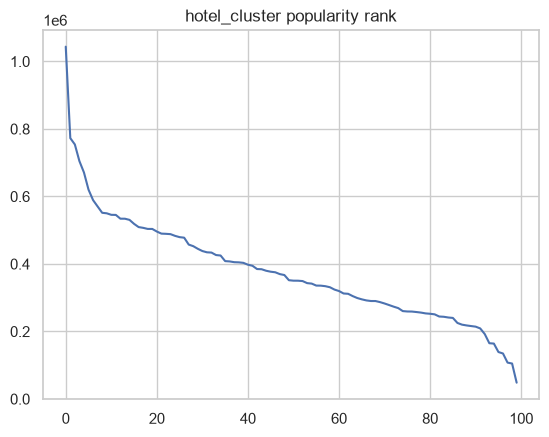

In [10]:
print("hotel_cluster is the target: 100 classes (0-99).")
cluster_dist = pd.Series(hotel_cluster_counts).sort_values(ascending=False)
print("most popular cluster share:", f"{cluster_dist.iloc[0]/n_rows:.2%}", "| least popular:", f"{cluster_dist.iloc[-1]/n_rows:.4%}")
cluster_dist.reset_index(drop=True).plot(title="hotel_cluster popularity rank"); plt.show()

Moderate imbalance across 100 classes, not as extreme as Airbnb's NDF dominance — still a real skew to account for in class weighting.

## 7. Bivariate / Correlation Analysis

In [11]:
is_booking_share_by_site = preview.groupby("site_name")["is_booking"].mean().sort_values(ascending=False)
print("is_booking rate by site_name (preview sample, top 10):")
is_booking_share_by_site.head(10)

is_booking rate by site_name (preview sample, top 10):


site_name
16    0.214286
19    0.172414
26    0.146465
40    0.138756
22    0.105263
44    0.100000
13    0.089135
2     0.086934
37    0.085805
33    0.083012
Name: is_booking, dtype: float64

## 8. Time-based Checks

In [12]:
print("date_time range:", dt_min, "to", dt_max)

date_time range: 2013-01-07 00:00:02 to 2014-12-31 23:59:59


Matches documented train/test time split (train = 2013-2014 logs, test = 2015 bookings only).

## 9. Data Consistency

In [13]:
print("is_booking values are 0/1 only (by dtype construction, int8 with value_counts):", dict(is_booking_counts))
print("hotel_cluster range check: min", min(hotel_cluster_counts), "max", max(hotel_cluster_counts))

is_booking values are 0/1 only (by dtype construction, int8 with value_counts): {0: 34669600, 1: 3000693}
hotel_cluster range check: min 0 max 99


## 10. Feature Relationships for Recommendation Context
`user_id` x `hotel_cluster`, restricted to `is_booking == 1` rows (actual bookings, not noisy clicks) — the real recommendation signal.

In [14]:
n_booking_rows = sum(is_booking_counts.values()) if False else is_booking_counts.get(1, 0)
n_users_booked = len(booking_user_counts)
n_clusters_booked = len(booking_cluster_counts)
n_pairs = len(booking_user_cluster_pairs)
sparsity = 1 - n_pairs / (n_users_booked * n_clusters_booked)
print(f"booking rows={n_booking_rows} users(booked)={n_users_booked} clusters(booked)={n_clusters_booked} pairs={n_pairs} sparsity={sparsity:.4%}")

booking rows=3000693 users(booked)=813985 clusters(booked)=100 pairs=2360713 sparsity=97.0998%


In [15]:
single_booking_users = (pd.Series(booking_user_counts) <= 1).sum()
print("users with only 1 booking:", single_booking_users, f"({single_booking_users/n_users_booked:.1%})")
print("note: total click+book rows =", n_rows, "but only", n_booking_rows, f"({n_booking_rows/n_rows:.2%}) are actual bookings — rest are search clicks (cnt/is_booking distinguishes).")

users with only 1 booking: 315679 (38.8%)
note: total click+book rows = 37670293 but only 3000693 (7.97%) are actual bookings — rest are search clicks (cnt/is_booking distinguishes).


## 11. Summary

- Shape: 37,670,293 rows (biggest dataset pulled), 24 columns — analyzed via chunked streaming pass (dtype-optimized) instead of full load, same constraint as Trivago.
- Missing values concentrated in `orig_destination_distance` (35.9%) and `srch_ci`/`srch_co` (0.12% each) — structural for searches without prior location/date context, not random. All other 21 columns 0% missing.
- 3,165 approx (hash-based) duplicate 4-key rows (0.0084%) — negligible.
- Confirmed critical structure: of 37.67M rows only 3,000,693 (7.97%) are actual bookings (`is_booking == 1`), rest are search clicks — the two must not be treated as equal-weight interactions.
- `hotel_cluster` (target, 100 classes) shows moderate popularity imbalance: most popular cluster 2.77% share, least popular 0.13% — real skew but far less extreme than Airbnb's NDF-dominated target.
- Found 798 rows (0.0021%) with `srch_co < srch_ci` invalid date ordering — real data-quality bug, tiny rate, filter before any stay-duration feature.
- Recommendation core: restricting to actual bookings only — 813,985 users, all 100 clusters represented, sparsity 97.1%. 38.8% of booking users have only 1 booking ever — cold-start present but less severe than Trivago's 56%.
- Time range confirmed matches documented competition split: train activity spans 2013-01-07 to 2014-12-31, test held out separately for 2015 bookings.
- Largest, most numeric-heavy dataset in this project; needs the click-vs-book distinction resolved before it can feed a CF/ranking pipeline.